# EV Charging Station Feasibility & Financial Analysis — Delhi vs Hyderabad

**Decision question:** Should a charge-point operator (CPO) invest in one public EV charging station (rented site, 10-year horizon) in Delhi, in Hyderabad, in both or in neither, and under what conditions?

*Portfolio feasibility study for a hypothetical CPO. Not a real client engagement. Every external number is in `docs/source_register.md`; every assumption is in `data/processed/assumptions.csv`.*

Each section answers: **What are we trying to answer? → What does the data show? → What business implication follows?**

In [1]:
import os, sys
os.chdir("..") if os.path.basename(os.getcwd()) == "notebooks" else None
sys.path.insert(0, "src")
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
from IPython.display import Image, display
from analysis import run_model, break_even_kwh_per_day, configs, CITIES, SCENARIOS
LAKH = 100000

## 1. Business problem
**Question:** Is one public DC charging station a good investment, and where?

**Success tests (agreed before any results):** (1) NPV > 0 at the cost of capital, (2) IRR > cost of capital, (3) payback before chargers wear out, (4) break-even utilisation below what Indian public chargers actually achieve, (5) survives the conservative scenario.

**Scope:** rented site only (CPOs rarely buy land; land cost would swamp the result), customers = cab fleets first, private cars second; subsidies excluded (PM E-DRIVE charging funds go to government entities, not private CPOs).

## 2. Data sources and research notes
All 40 sourced numbers, each labelled FACT / ESTIMATE / ASSUMPTION / DERIVED, are in the source register. The central assumptions table below drives both this notebook and the Excel model.

In [2]:
assumptions = pd.read_csv("data/processed/assumptions.csv")
assumptions[["parameter", "city", "conservative", "base", "aggressive", "unit", "label"]]

,parameter,city,conservative,base,aggressive,unit,label
0,public_demand_kwh_per_day,Delhi,"41,641.00","41,641.00","41,641.00",kWh/day,DERIVED
1,public_demand_kwh_per_day,Hyderabad,"38,471.00","38,471.00","38,471.00",kWh/day,DERIVED
2,fast_stations,Delhi,399.00,399.00,399.00,stations,FACT
3,fast_stations,Hyderabad,373.00,373.00,373.00,stations,DERIVED
4,capture_multiple,All,0.75,1.25,2.00,x fair share,ASSUMPTION
5,year1_ramp,All,0.60,0.70,0.80,share of steady demand,ASSUMPTION
6,demand_growth_per_station,All,0.00,0.07,0.12,per year,ASSUMPTION
7,kwh_per_session,All,20.00,20.00,20.00,kWh,ASSUMPTION
8,price_net_of_gst,Delhi,16.94,18.64,19.06,Rs/kWh,DERIVED
9,price_net_of_gst,Hyderabad,13.00,16.00,18.64,Rs/kWh,ASSUMPTION


## 3. Market data and city selection
**Question:** Which cities have the most new electric cars per existing fast charger?

**Data:** PIB Lok Sabha reply (Dec 2025) for stations; EVreporter/Vahan for FY26 e-car sales.

In [3]:
screen = pd.read_csv("data/raw/city_screen_inputs.csv")
screen["annual_sales"] = screen["e4w_sales_fy26"] / screen["e4w_months_covered"] * 12
screen["new_ecars_per_fast_station"] = screen["annual_sales"] / screen["pcs_fast"]
screen[["city", "annual_sales", "pcs_fast", "new_ecars_per_fast_station", "ev_energy_charge_rs_kwh"]].sort_values("new_ecars_per_fast_station", ascending=False)

,city,annual_sales,pcs_fast,new_ecars_per_fast_station,ev_energy_charge_rs_kwh
2,Delhi,"16,986.00",399,42.57,4.50
0,Hyderabad,"21,610.91",548,39.44,6.00
1,Bengaluru,"24,201.00",751,32.23,4.50
3,Pune,"34,066.00",1205,28.27,NaN
4,Ranchi,NaN,129,NaN,NaN


**Implication:** Delhi (42.6) and Hyderabad (39.4) lead and are close, so both were studied in full. Ranchi was dropped: Jharkhand had only ~1,475 e-cars in total (≈11 per fast station).

## 4. Data cleaning
Main cleaning steps (all in code, nothing edited by hand):
- Telangana FY26 sales cover 11 months → pro-rated to 12.
- Telangana figures scaled to Hyderabad with the 68% share of state EVs registered in Hyderabad, Rangareddy and Medchal (ETV Bharat) — labelled ASSUMPTION when applied to cars.
- Competitor price ranges ("21.99-22.99") converted to mid-points; listed prices assumed to include 18% GST.

## 5. Market analysis and sizing (TAM / SAM / SOM)
**Question:** How much charging energy do e-cars need, and how much is bought at public chargers?

- **TAM** = e-cars × km per year × kWh per km (all charging, anywhere)
- **SAM** = TAM × share charged in public (private cars 10%, cabs 30%)
- **SOM** = our station's share of SAM = SAM ÷ existing fast stations × capture multiple (Section 8)

In [4]:
market = pd.read_csv("outputs/tables/market_sizing.csv")
market[["city", "ecar_stock", "tam_mwh_per_year", "sam_mwh_per_year", "cab_share_of_sam_pct", "sam_kwh_per_station_per_day"]]

,city,ecar_stock,tam_mwh_per_year,sam_mwh_per_year,cab_share_of_sam_pct,sam_kwh_per_station_per_day
0,Delhi,"45,435.70","80,425.70","15,198.70",70.60,104.40
1,Hyderabad,"41,976.50","74,302.70","14,041.60",70.60,103.20


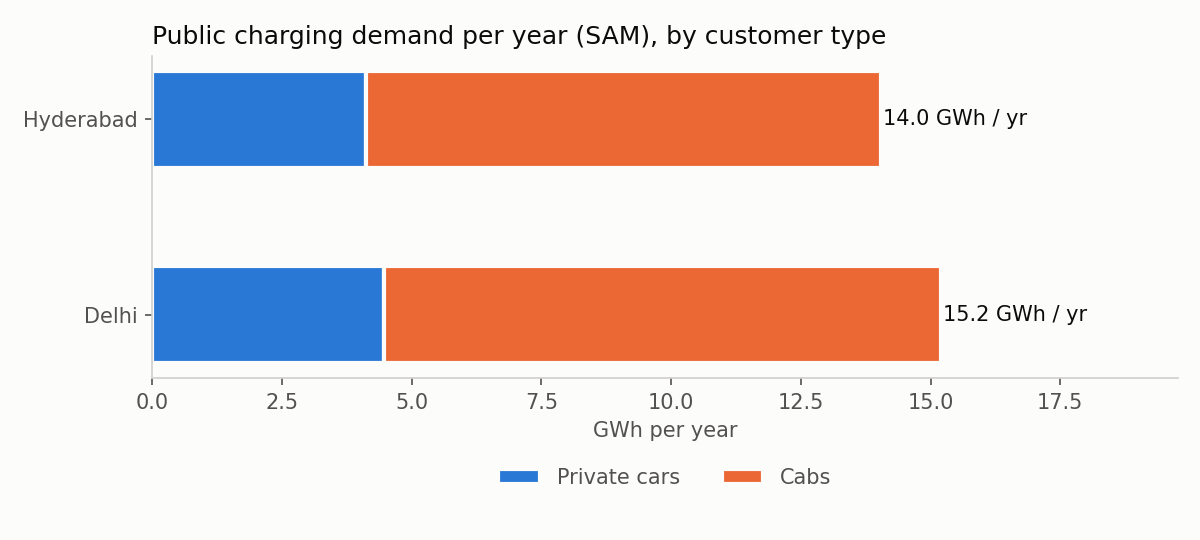

In [5]:
display(Image("outputs/charts/phase4_sam_by_segment.png"))

**Validation:** if all public demand were spread over existing fast stations, each would sell ~104 kWh/day. An independent national study (8.36% utilisation of a 50 kW charger) gives ~100 kWh/day. The two methods agree.

**Implication:** both cities have ~15 GWh/yr of public demand; cabs are ~15% of cars but ~70% of public charging, so cab behaviour decides the business.

## 6. Competitor analysis
**Question:** What do nearby rivals charge, and is there a gap?

In [6]:
comp = pd.read_csv("outputs/tables/competitor_matrix.csv")
comp[["city", "station", "area", "dc_power_kw", "dc_price_mid", "status_seen", "label"]]

,city,station,area,dc_power_kw,dc_price_mid,status_seen,label
0,Delhi,GMR Aerocity Parking (CCS),Aerocity,60,19.99,1 of 3 chargers faulted,OBSERVED (web listing)
1,Delhi,Statiq Mahipalpur Hub,Mahipalpur (airport),25-120,22.49,operational; some connectors faulted; 14137 re...,OBSERVED (web listing)
2,Delhi,GLIDA DLF Avenue,Saket (South Delhi),60,21.99,all connectors faulted,OBSERVED (web listing)
3,Delhi,Tata Power EZ Charge (network),Delhi NCR,30-60,18.50,NaN,REPORTED (secondary)
4,Delhi,Jio-bp pulse (network),National headline,NaN,19.25,NaN,REPORTED (operator site; state rates vary)
5,Hyderabad,Divyasree Trinity,HITEC City / Madhapur,120,24.99,1 of 2 DC unavailable,OBSERVED (web listing)
6,Hyderabad,DivyaSree Solitaire,Inorbit Mall Rd (HITEC City),120,21.99,currently unavailable,OBSERVED (web listing)
7,Hyderabad,Spider SLN Gachibowli,Gachibowli,120,21.99,both chargers faulted,OBSERVED (web listing)
8,Hyderabad,TSIIC IOCL Bunk,Gachibowli,60,13.00,open; reviews report one gun not working,OBSERVED (web listing)
9,Hyderabad,TGREDCO public network (200 stations),Greater Hyderabad / Cyberabad / Malkajgiri,NaN,13.00,tender closed 22 Sep 2026; 10-year fixed price...,REPORTED (press)


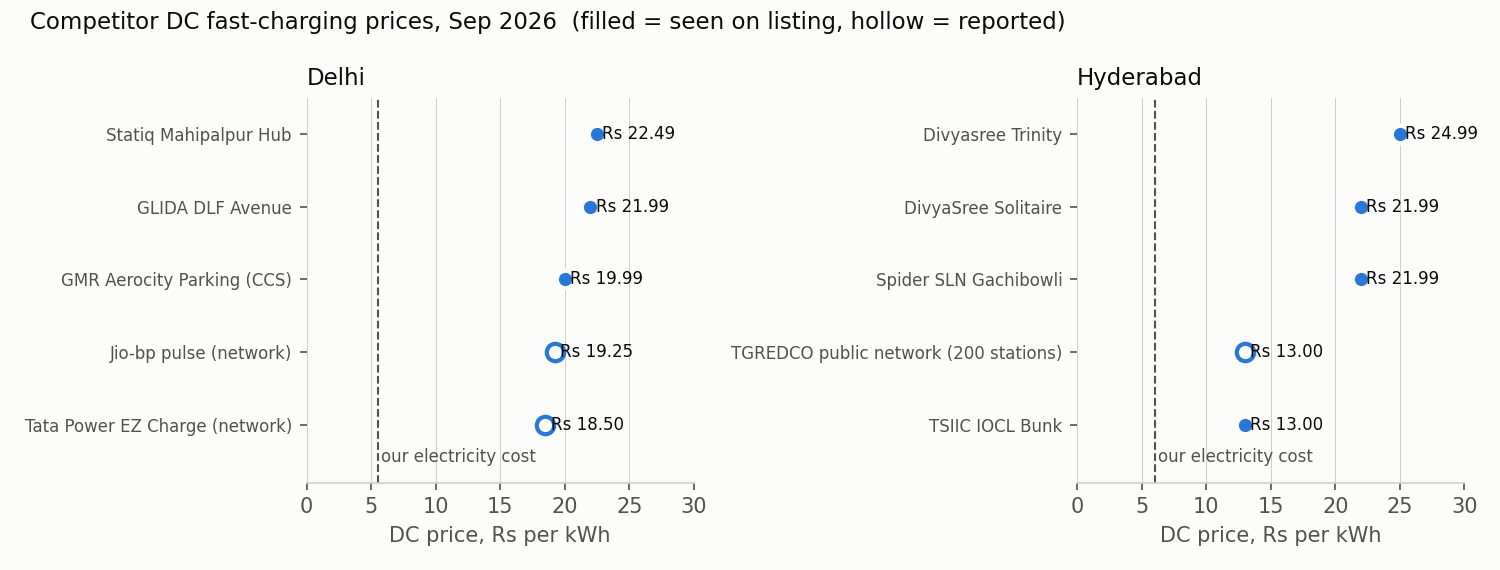

In [7]:
display(Image("outputs/charts/phase5_competitor_prices.png"))

**Implication:** Delhi private prices are ₹20–22; Hyderabad private prices are similar but a **₹13 government network (200 stations, fixed for 10 years)** is arriving. Many listed chargers were faulted, so reliability is the only evidence-backed edge. Limitation: 3 private price points per city, from one platform, on one date.

## 7. Demand estimation
**Question:** How much will our one station sell?

Year-1 demand (kWh/day) = public demand ÷ existing fast stations × capture multiple × ramp-up. Then it grows each year by the per-station growth rate, capped by what the chargers can physically deliver.

In [8]:
rows = []
for city in CITIES:
    for sc in SCENARIOS:
        t = run_model(city, sc, "A")["table"]
        rows.append({"city": city, "scenario": sc, "yr1_kwh_day": t.loc[0, "kwh_per_day"], "yr1_sessions": t.loc[0, "sessions_per_day"],
                     "yr5_kwh_day": t.loc[4, "kwh_per_day"], "yr10_kwh_day": t.loc[9, "kwh_per_day"]})
pd.DataFrame(rows)

,city,scenario,yr1_kwh_day,yr1_sessions,yr5_kwh_day,yr10_kwh_day
0,Delhi,conservative,46.96,2.35,78.27,78.27
1,Delhi,base,91.32,4.57,171.00,239.83
2,Delhi,aggressive,166.98,8.35,328.44,477.52
3,Hyderabad,conservative,46.41,2.32,77.35,77.35
4,Hyderabad,base,90.25,4.51,168.99,237.02
5,Hyderabad,aggressive,165.02,8.25,324.58,477.52


## 8. Station configuration
**Question:** One charger, two, or a fleet hub?

In [9]:
pd.read_csv("outputs/tables/config_comparison.csv")

,city,config,description,capex_lakh,yr1_utilisation_pct,npv_lakh,irr_pct
0,Delhi,A,Lean: 1 x 60 kW DC + 2 x 7.4 kW AC,31.18,7.27,-25.39,NaN
1,Delhi,B,Balanced: 2 x 60 kW DC + 2 x 7.4 kW AC,46.96,4.03,-45.34,NaN
2,Delhi,C,Fleet hub: 2 x 120 kW DC + 2 x 7.4 kW AC,64.14,2.13,-66.39,NaN
3,Hyderabad,A,Lean: 1 x 60 kW DC + 2 x 7.4 kW AC,31.18,7.18,-34.85,NaN
4,Hyderabad,B,Balanced: 2 x 60 kW DC + 2 x 7.4 kW AC,46.96,3.99,-54.79,NaN
5,Hyderabad,C,Fleet hub: 2 x 120 kW DC + 2 x 7.4 kW AC,64.14,2.11,-95.93,NaN


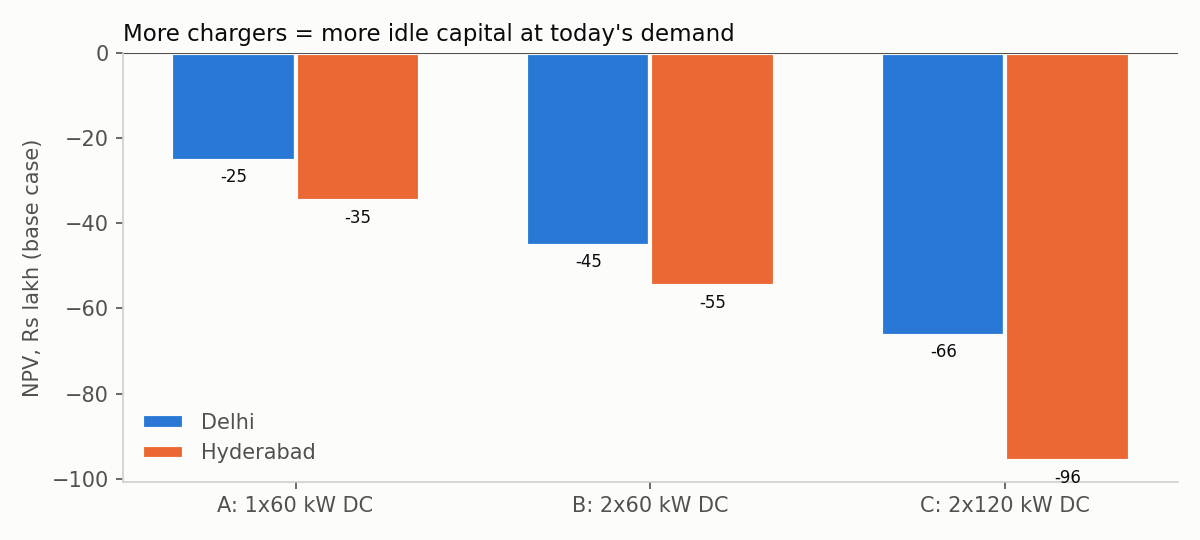

In [10]:
display(Image("outputs/charts/config_npv.png"))

**Implication:** at realistic demand the extra chargers sit idle, so the lean option **A (1 × 60 kW DC + 2 × 7.4 kW AC)** has the highest NPV in both cities. The rest of the analysis uses A.

## 9. Financial assumptions
Discount rate = risk-free 7.02% (10-year G-sec) + beta 1.0 × India equity risk premium 7.08% (Damodaran) = **14.1%**. Tax 25.17% (Sec 115BAA). Straight-line depreciation over 10 years, no salvage. Working capital = one month of year-1 running costs, returned in year 10.

## 10. CAPEX model

In [11]:
r = run_model("Delhi", "base", "A")
pd.Series(r["capex"]).div(LAKH).rename("Rs lakh")

chargers         9.30
upstream_grid   14.80
civil            3.00
other            1.25
contingency      2.83
total           31.18
Name: Rs lakh, dtype: float64

The grid connection (₹14.8 lakh, MHI benchmark) is almost half the setup cost — a key lever later.

## 11. OPEX, 12. Revenue, 13. P&L and 14. Cash flow (Delhi base case, Rs lakh)

In [12]:
t = r["table"].copy()
cols = ["revenue", "electricity", "gross_profit", "host_rent", "staff", "maintenance", "software", "payment_fees",
        "insurance", "misc", "ebitda", "tax", "net_cash_flow", "cumulative_cash_flow"]
t[cols] = t[cols] / LAKH
t[["year", "kwh_per_day", "sessions_per_day", "utilisation"] + cols].round(2)

,year,kwh_per_day,sessions_per_day,utilisation,revenue,electricity,gross_profit,host_rent,staff,maintenance,software,payment_fees,insurance,misc,ebitda,tax,net_cash_flow,cumulative_cash_flow
0,1,91.32,4.57,0.07,6.21,1.89,4.32,0.93,2.40,0.46,0.54,0.09,0.16,0.60,-0.86,0.00,-0.86,-32.64
1,2,139.59,6.98,0.11,9.69,2.98,6.71,1.45,2.52,0.49,0.57,0.15,0.16,0.63,0.74,0.00,0.74,-31.89
2,3,149.36,7.47,0.12,10.57,3.28,7.29,1.59,2.65,0.51,0.60,0.16,0.17,0.66,0.96,0.00,0.96,-30.93
3,4,159.81,7.99,0.13,11.54,3.61,7.92,1.73,2.78,0.54,0.63,0.17,0.18,0.69,1.20,0.00,1.20,-29.73
4,5,171.00,8.55,0.14,12.59,3.98,8.61,1.89,2.92,0.57,0.66,0.19,0.19,0.73,1.47,0.00,1.47,-28.25
5,6,182.97,9.15,0.15,13.74,4.39,9.35,2.06,3.06,0.59,0.69,0.21,0.20,0.77,1.78,0.00,1.78,-26.48
6,7,195.78,9.79,0.16,15.00,4.84,10.16,2.25,3.22,0.62,0.72,0.23,0.21,0.80,2.11,0.00,2.11,-24.37
7,8,209.48,10.47,0.17,16.37,5.33,11.04,2.46,3.38,0.65,0.76,0.25,0.22,0.84,2.48,0.00,2.48,-21.88
8,9,224.14,11.21,0.18,17.87,5.88,11.99,2.68,3.55,0.69,0.80,0.27,0.23,0.89,2.90,0.00,2.90,-18.99
9,10,239.83,11.99,0.19,19.50,6.48,13.02,2.93,3.72,0.72,0.84,0.29,0.24,0.93,3.35,0.00,3.94,-15.05


In [13]:
pd.read_csv("outputs/tables/cashflow_hyderabad_base.csv")[["year", "kwh_per_day", "revenue", "electricity", "ebitda", "net_cash_flow", "cumulative_cash_flow"]]

,year,kwh_per_day,revenue,electricity,ebitda,net_cash_flow,cumulative_cash_flow
0,1,90.25,5.27,2.05,-1.81,-1.81,-33.59
1,2,137.95,8.22,3.22,-0.73,-0.73,-34.32
2,3,147.61,8.97,3.55,-0.65,-0.65,-34.97
3,4,157.94,9.79,3.91,-0.56,-0.56,-35.52
4,5,168.99,10.68,4.31,-0.45,-0.45,-35.97
5,6,180.82,11.66,4.75,-0.32,-0.32,-36.30
6,7,193.48,12.72,5.23,-0.18,-0.18,-36.48
7,8,207.02,13.89,5.77,-0.02,-0.02,-36.50
8,9,221.52,15.16,6.35,0.16,0.16,-36.35
9,10,237.02,16.54,7.00,0.36,0.95,-35.40


## 15. Unit economics
**Question:** Does each unit sold make money?

In [14]:
pd.read_csv("outputs/tables/unit_economics.csv")

,city,year,revenue_per_kwh,electricity_per_kwh,contribution_per_kwh,other_opex_per_kwh,ebitda_per_kwh,revenue_per_session,contribution_per_session
0,Delhi,1,18.64,5.67,9.89,12.48,-2.59,372.80,197.89
1,Delhi,5,20.18,6.38,10.47,8.10,2.36,403.53,209.31
2,Hyderabad,1,16.00,6.23,7.13,12.63,-5.50,320.00,142.61
3,Hyderabad,5,17.32,6.99,7.47,8.20,-0.73,346.38,149.46


**Implication:** each unit earns ₹7–10 after electricity, host share and payment fees, but fixed costs of ~₹4 lakh a year swamp this at 4–5 cars a day. Volume, not margin per unit, is the problem.

## 16. Financial feasibility (NPV, IRR, payback)

In [15]:
scen = pd.read_csv("outputs/tables/scenarios.csv")
scen[scen["scenario"] == "base"][["city", "capex_lakh", "npv_lakh", "irr_pct", "payback_years"]]

,city,capex_lakh,npv_lakh,irr_pct,payback_years
1,Delhi,31.18,-25.39,NaN,NaN
4,Hyderabad,31.18,-34.85,NaN,NaN


IRR is reported as n/a when the project never gets its money back, because a negative IRR is not a meaningful return.

## 17. Break-even analysis
**Question:** How busy must the station be?

Break-even is found by solving the full 10-year model for NPV = 0 (bisection), so it uses the project's real cost structure — not a generic formula.

In [16]:
scen[["city", "scenario", "breakeven_npv_kwh_day", "breakeven_npv_sessions_day", "breakeven_npv_utilisation_pct",
      "breakeven_ebitda_utilisation_pct", "yr1_utilisation_pct", "yr5_utilisation_pct"]]

,city,scenario,breakeven_npv_kwh_day,breakeven_npv_sessions_day,breakeven_npv_utilisation_pct,breakeven_ebitda_utilisation_pct,yr1_utilisation_pct,yr5_utilisation_pct
0,Delhi,conservative,NaN,NaN,NaN,21.30,3.74,6.23
1,Delhi,base,320.82,16.04,25.53,9.17,7.27,13.61
2,Delhi,aggressive,200.66,10.03,15.97,5.18,13.29,26.14
3,Hyderabad,conservative,NaN,NaN,NaN,NaN,3.69,6.16
4,Hyderabad,base,450.26,22.51,35.83,12.69,7.18,13.45
5,Hyderabad,aggressive,228.41,11.42,18.18,5.93,13.13,25.83


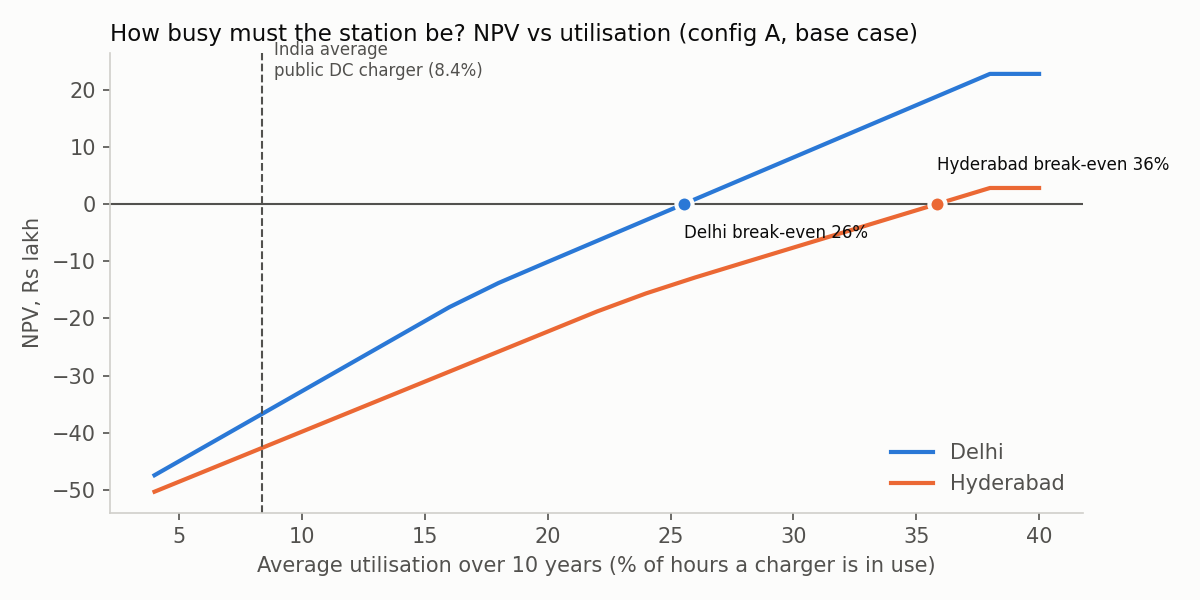

In [17]:
display(Image("outputs/charts/npv_vs_utilisation.png"))

**Implication:** base-case break-even needs **25.5% (Delhi) / 35.8% (Hyderabad)** utilisation every year — 3–4× the 8.4% national average.

## 18. Scenario analysis

In [18]:
scen[["city", "scenario", "yr1_revenue_lakh", "yr1_ebitda_lakh", "yr5_ebitda_margin_pct", "npv_lakh", "irr_pct", "payback_years", "breakeven_npv_utilisation_pct"]]

,city,scenario,yr1_revenue_lakh,yr1_ebitda_lakh,yr5_ebitda_margin_pct,npv_lakh,irr_pct,payback_years,breakeven_npv_utilisation_pct
0,Delhi,conservative,2.90,-5.66,-138.85,-70.82,NaN,NaN,NaN
1,Delhi,base,6.21,-0.86,11.71,-25.39,NaN,NaN,25.53
2,Delhi,aggressive,11.62,4.41,49.94,22.55,27.20,4.20,15.97
3,Hyderabad,conservative,2.20,-6.30,-212.54,-76.06,NaN,NaN,NaN
4,Hyderabad,base,5.27,-1.81,-4.19,-34.85,NaN,NaN,35.83
5,Hyderabad,aggressive,11.23,3.44,43.25,14.88,23.10,4.80,18.18


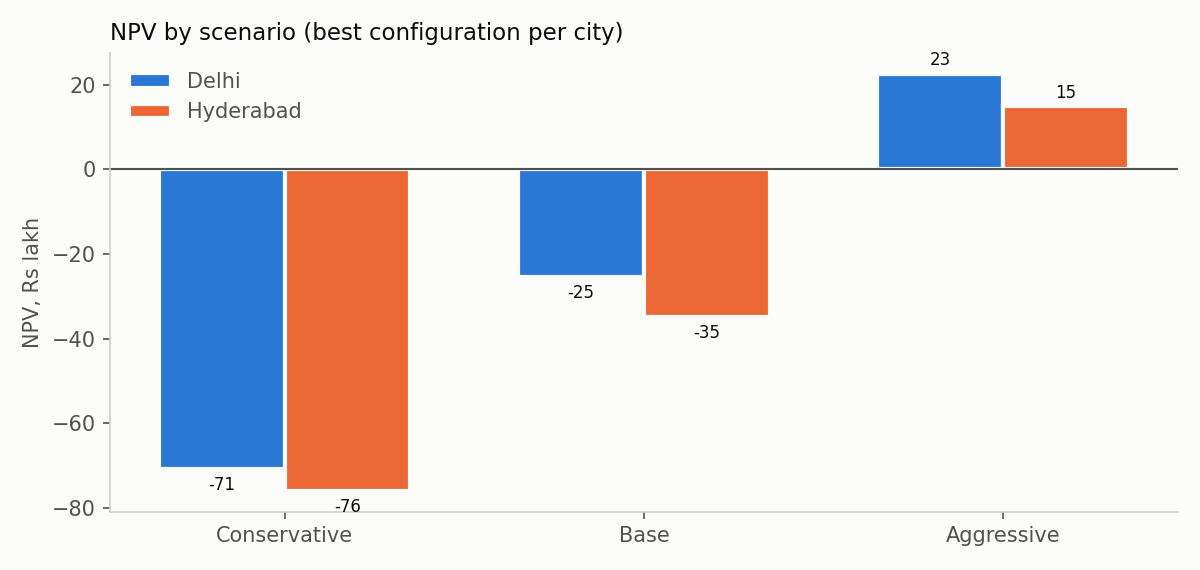

In [19]:
display(Image("outputs/charts/scenario_npv.png"))

## 19. Sensitivity analysis
**Question:** Which assumption matters most?

In [20]:
pd.read_csv("outputs/tables/sensitivity_tornado.csv")

,city,input,base_npv_lakh,npv_bad_lakh,npv_good_lakh,swing_lakh
0,Delhi,Staff 2 FTE / 0 FTE,-25.39,-40.43,-11.70,28.73
1,Delhi,Demand (capture) -30% / +30%,-25.39,-34.95,-16.23,18.72
2,Delhi,Grid work: new connection / host's spare capacity,-25.39,-25.39,-8.76,16.64
3,Delhi,CAPEX +20% / -20%,-25.39,-32.13,-18.66,13.46
4,Delhi,Charging price -10% / +10%,-25.39,-30.55,-20.23,10.32
5,Delhi,Electricity cost +20% / -20%,-25.39,-29.34,-21.45,7.90
6,Delhi,Host revenue share 20% / 10%,-25.39,-28.51,-22.28,6.23
7,Delhi,Discount rate 16% / 12%,-25.39,-26.09,-24.50,1.60
8,Hyderabad,Staff 2 FTE / 0 FTE,-34.85,-49.88,-19.82,30.07
9,Hyderabad,Grid work: new connection / host's spare capacity,-34.85,-34.85,-18.06,16.79


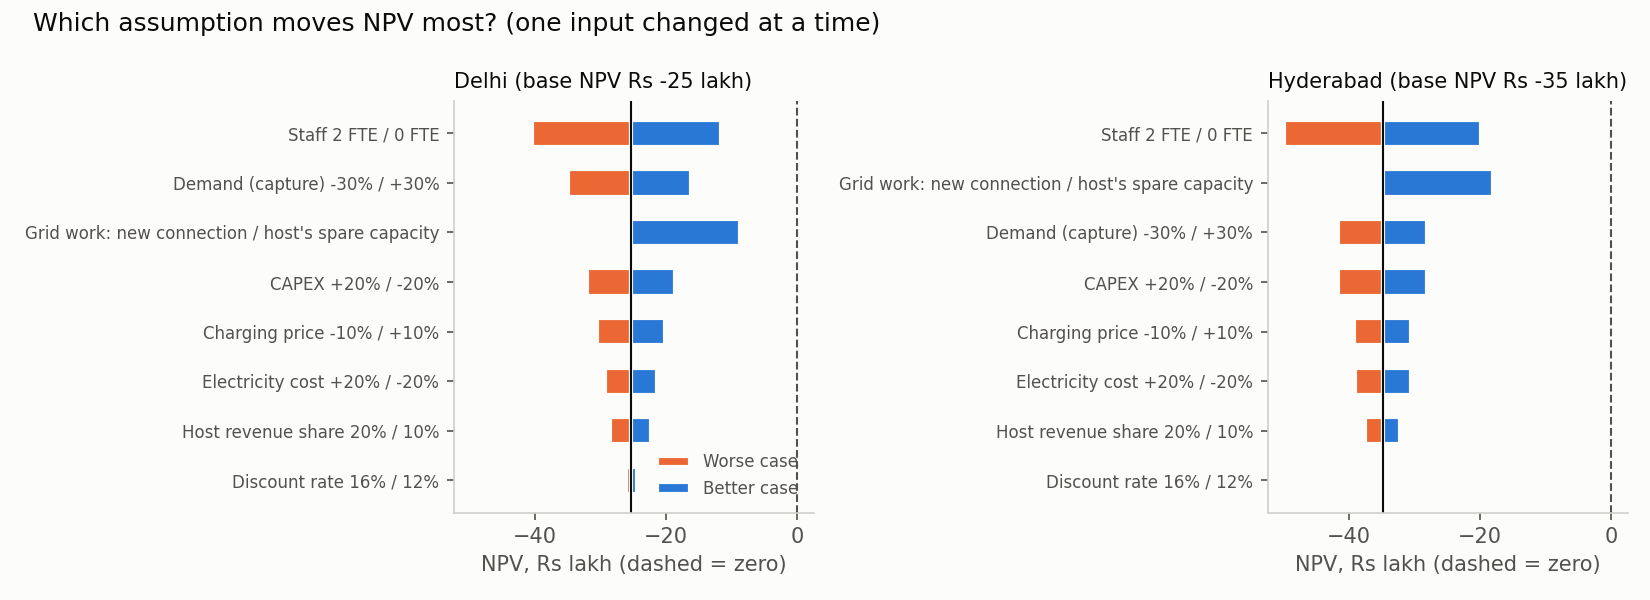

In [21]:
display(Image("outputs/charts/tornado.png"))

**Implication:** staffing (0–2 people), demand and the grid-connection cost move NPV most. The discount rate barely matters — the problem is volume, not financing.

**What would it take?** Stacking the three levers management can negotiate:

In [22]:
pd.read_csv("outputs/tables/levers.csv")

,city,step,capex_lakh,npv_lakh,irr_pct,payback_years
0,Delhi,Base case,31.18,-25.39,NaN,NaN
1,Delhi,+ host site with spare grid capacity,14.90,-8.76,1.40,9.50
2,Delhi,+ unmanned (remote-monitored),14.90,2.94,18.00,5.10
3,Delhi,+ host share cut to 10%,14.90,5.27,20.90,4.70
4,Delhi,Break-even utilisation with all levers (%),NaN,10.38,NaN,NaN
5,Hyderabad,Base case,31.18,-34.85,NaN,NaN
6,Hyderabad,+ host site with spare grid capacity,14.90,-18.06,NaN,NaN
7,Hyderabad,+ unmanned (remote-monitored),14.90,-4.17,7.80,7.40
8,Hyderabad,+ host share cut to 10%,14.90,-2.17,11.00,6.50
9,Hyderabad,Break-even utilisation with all levers (%),NaN,14.33,NaN,NaN


In [23]:
pd.read_csv("outputs/tables/levers_by_scenario.csv")

,city,scenario,npv_lakh,irr_pct,payback_years
0,Delhi,conservative,-19.09,NaN,NaN
1,Delhi,base,5.27,20.90,4.70
2,Delhi,aggressive,41.28,54.00,2.30
3,Hyderabad,conservative,-24.89,NaN,NaN
4,Hyderabad,base,-2.17,11.00,6.50
5,Hyderabad,aggressive,33.61,47.50,2.60


## 20. Risk analysis

| Risk | Type | Likelihood (why) | Impact | Mitigation |
|---|---|---|---|---|
| Cab fleets charge at own depots | Modelled (cab public share 30%) | High — BluSmart's successors run private hubs | Cabs are ~70% of SAM; halving their share roughly halves demand | Sign a fleet offtake letter before building |
| Charger supply outpaces cars | Modelled (per-station growth 0–12%) | High — Delhi targets 16,000+ points by end-2026 | Utilisation stays near 8% | Choose a site with no rival within walking distance; stay lean |
| Price war with ₹13 government network (Hyderabad) | Modelled (₹13 case: NPV −₹43 lakh) | High — tender closed 22 Sep 2026 | Margin per unit halves | Do not enter Hyderabad now |
| Electricity surcharges higher than assumed (Delhi) | Assumption | Medium — PPAC applicability unverified | +20% tariff = −₹4 lakh NPV | Get DISCOM confirmation |
| Charger downtime | Modelled (95% uptime) | Medium — many rivals seen faulted | Lost sessions, reputation | AMC with uptime SLA |
| Telangana road-tax waiver lapses (Dec 2026) | Unknown | Uncertain — extension proposed, not approved | Slower e-car growth | Revisit Hyderabad after decision |
| Host terms / site access | Unknown, needs due diligence | — | Levers depend on it | Term sheet before capital |

## 21. Key findings
1. Both cities have similar public demand (~15 GWh/yr), driven ~70% by cabs.
2. The lean one-charger station beats bigger hubs; extra chargers are idle capital.
3. Base case fails in both cities: NPV −₹25.4 lakh (Delhi), −₹34.8 lakh (Hyderabad).
4. Break-even needs 25.5% / 35.8% utilisation vs 8.4% national average.
5. Delhi turns positive (NPV +₹5.3 lakh, IRR 20.9%, payback 4.7 years) only with a host site that has spare grid capacity, an unmanned station and a ≤10% host share — and still fails the conservative case.
6. Hyderabad stays negative even with all levers (−₹2.2 lakh), mainly because of the ₹13 government price network.

## 22. Recommendation
Under the base-case assumptions the lean station reaches only 7% utilisation in year 1 (13–14% by year 5), EBITDA is negative in year 1 and the project never recovers its ₹31 lakh cost in either city. The project becomes financially unattractive below roughly 25% utilisation in Delhi and 36% in Hyderabad.

- **Delhi — viable only after specific modifications:** proceed only as a pilot of one 60 kW charger at a host site with spare grid capacity, unmanned, host share ≤ 10% (NPV +₹5.3 lakh, IRR 20.9%). Because it fails the conservative scenario, commit capital only after a host term sheet, a cab-fleet offtake letter and DISCOM confirmation of surcharges.
- **Hyderabad — financially unattractive under the modelled assumptions:** do not invest now; revisit after the ₹13 TGREDCO network opens and the road-tax waiver decision (Dec 2026).

## 23. Limitations
- Delhi e-car stock is estimated from sales (no published total); Hyderabad uses a 68% share of Telangana.
- Cab share of cars (15%) and cab public-charging share (30%) are assumptions with no published source.
- Competitor prices: 3 private price points per city from one platform on one date; GST inclusion assumed.
- Delhi surcharges on the EV tariff and Telangana duty are not yet verified.
- Charger cost for 60/120 kW is interpolated from MHI benchmarks; maintenance, software and staff costs are assumptions.
- Demand growth per station is a judgement balancing EV growth against charger roll-out.
- Utilisation includes AC chargers in the capacity base; the national benchmark covers DC chargers only.

## Model audit

In [24]:
# Reconciliation checks: the model's own arithmetic
checks = {}
for city in CITIES:
    r = run_model(city, "base", "A")
    t = r["table"]
    checks[f"{city}: revenue = kWh x price (yr 1)"] = abs(t.loc[0, "revenue"] - t.loc[0, "kwh_per_day"] * 365 * 18.64 * (1 if city == "Delhi" else 16 / 18.64)) < 1
    checks[f"{city}: sold kWh <= capacity (all years)"] = (t["kwh_per_day"] <= r["capacity_kwh_day"] + 1e-6).all()
    checks[f"{city}: EBITDA = gross profit - opex"] = ((t["gross_profit"] - t["opex_excl_electricity"] - t["ebitda"]).abs() < 1).all()
    checks[f"{city}: cumulative = sum of cash flows"] = abs(t["cumulative_cash_flow"].iloc[-1] - sum(r["cash_flows"])) < 1
    be = break_even_kwh_per_day(city, "base", "A")
    checks[f"{city}: NPV at break-even demand ~ 0"] = abs(run_model(city, "base", "A", {"flat_demand_kwh_day": be})["npv"]) < 100
checks["Excel NPV = Python NPV (see Excel 'Checks' sheet)"] = "checked in workbook"
pd.Series(checks, name="result")

Delhi: revenue = kWh x price (yr 1)                                 True
Delhi: sold kWh <= capacity (all years)                             True
Delhi: EBITDA = gross profit - opex                                 True
Delhi: cumulative = sum of cash flows                               True
Delhi: NPV at break-even demand ~ 0                                 True
Hyderabad: revenue = kWh x price (yr 1)                             True
Hyderabad: sold kWh <= capacity (all years)                         True
Hyderabad: EBITDA = gross profit - opex                             True
Hyderabad: cumulative = sum of cash flows                           True
Hyderabad: NPV at break-even demand ~ 0                             True
Excel NPV = Python NPV (see Excel 'Checks' sheet)    checked in workbook
Name: result, dtype: object